In [36]:
from math import pi
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
%matplotlib inline

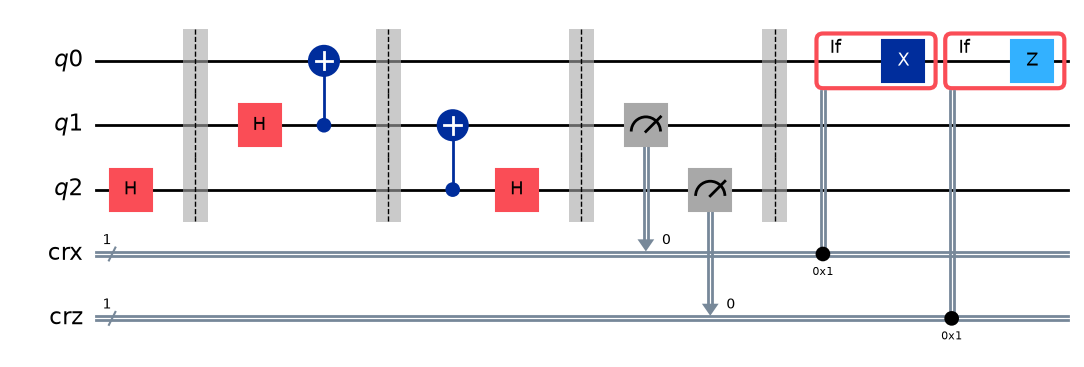

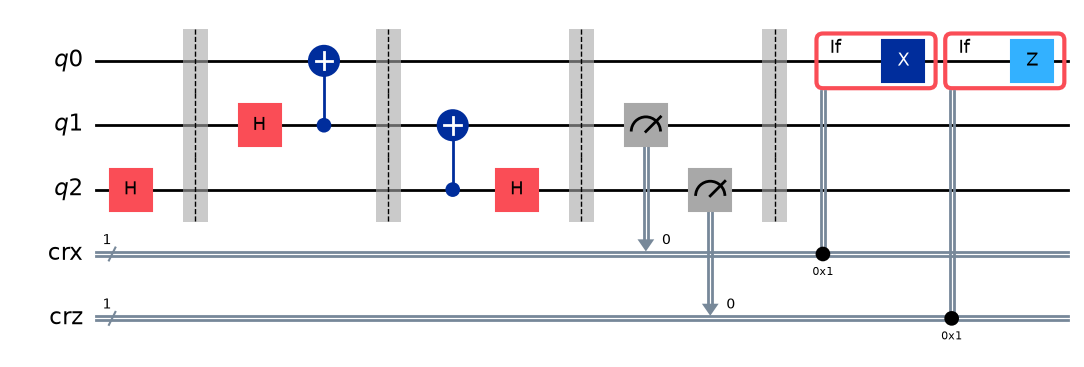

In [37]:
q0 = QuantumRegister(1, name='q0') # q0 is the destination qubit, which will be teleported to
q1 = QuantumRegister(1, name='q1') # q1 is the middle qubit sent to receiver
q2 = QuantumRegister(1, name='q2') # q2 is the source qubit, which will be teleported

crx = ClassicalRegister(1, name='crx') # classical bit 'crx' to store the measurement of bell's pair (middle qubit q1)
crz = ClassicalRegister(1, name='crz') # classical bit 'crz' to store the measurement of sender's qubit (source qubit q2)

circuit = QuantumCircuit(q0, q1, q2, crx, crz)

#initiliaze the source qubit q2 with a hadamard gate to create a superposition state
circuit.h(q2)
circuit.barrier()

#create a bell pair q1 and q0
circuit.h(q1)
circuit.cx(q1, q0)
circuit.barrier()

#perform a bell measurement on the source qubit q2 and the middle qubit q1
circuit.cx(q2, q1)
circuit.h(q2)
circuit.barrier()

circuit.measure(q1, crx)
circuit.measure(q2, crz)
circuit.barrier()

#apply the correction gates to the destination qubit q0 based on the measurement results
with circuit.if_test((crx, 1)):
  circuit.x(q0)
with circuit.if_test((crz, 1)):
  circuit.z(q0)

circuit.draw(output='mpl')

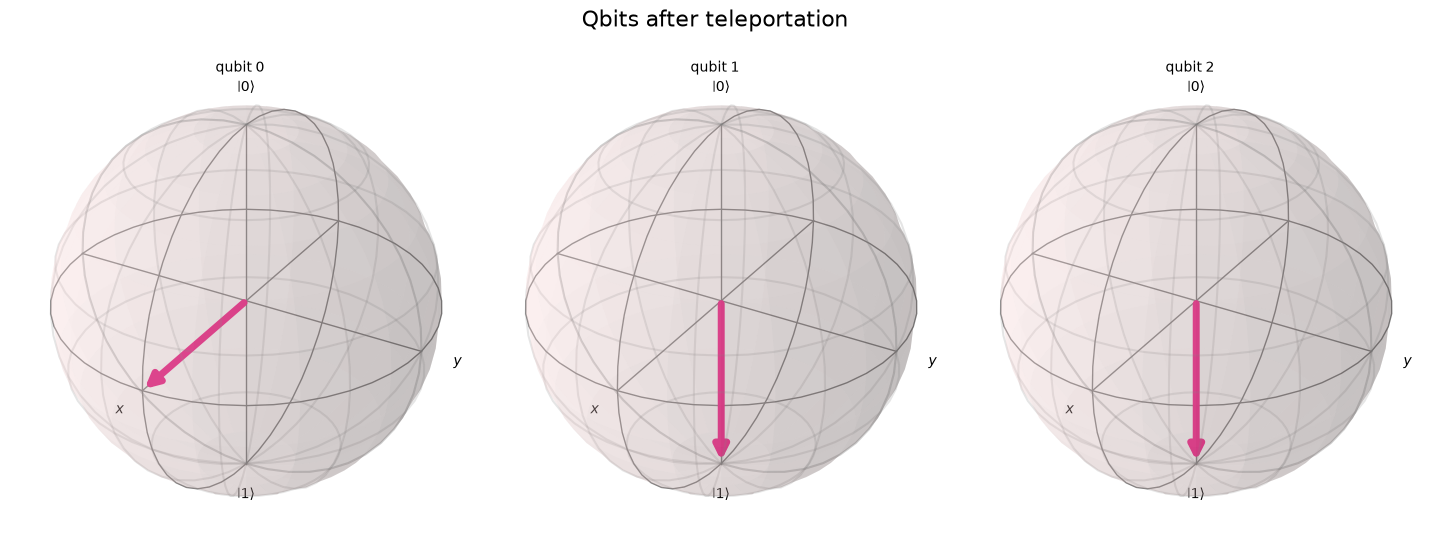

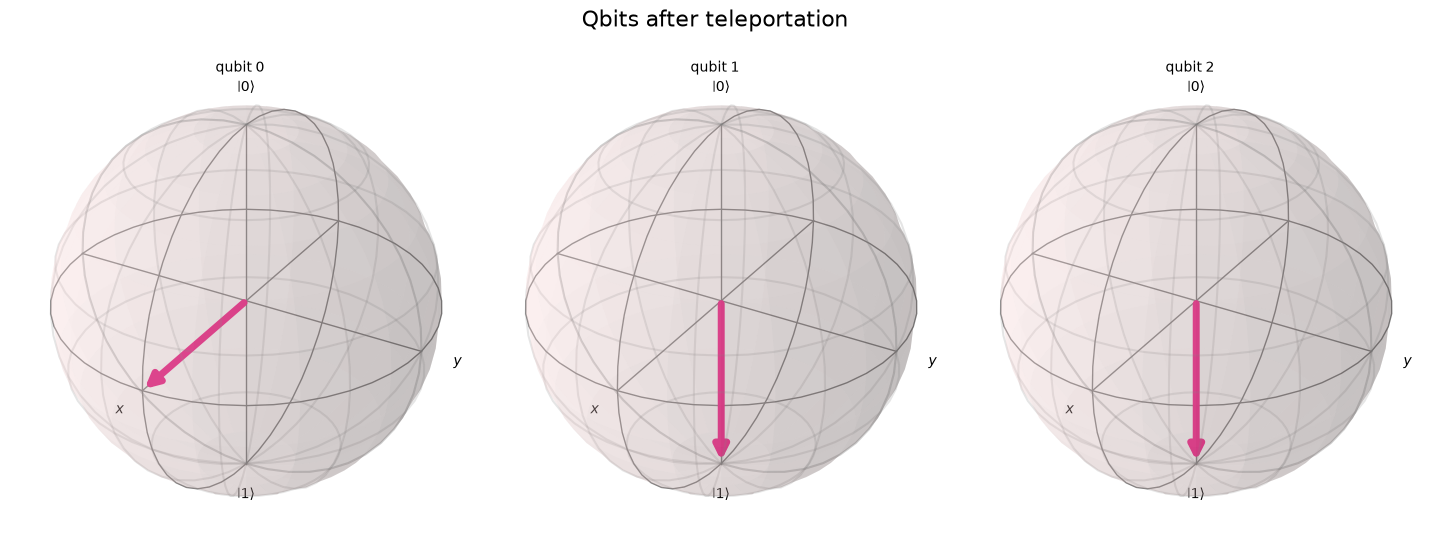

In [39]:
# State vector simulation of teleportation circuit
statevector_circuit = QuantumCircuit(3, 2)

statevector_circuit.h(2) #initialize the source qubit q2 with a hadamard gate to create a superposition state

#create a bell pair q1 and q0
statevector_circuit.h(1)
statevector_circuit.cx(1, 0)

#perform a bell measurement on the source qubit q2 and the middle qubit q1
statevector_circuit.cx(2, 1)
statevector_circuit.h(2)
statevector_circuit.measure(2, 0) #measure the source qubit q2 and store the result in classical bit 0
statevector_circuit.measure(1, 1) #measure the middle qubit q1 and store the result in classical bit 1

#apply the correction gates to the destination qubit q0 based on the measurement results
with statevector_circuit.if_test((statevector_circuit.clbits[0], 1)): #if the first measurement result is 1
  statevector_circuit.x(0)
with statevector_circuit.if_test((statevector_circuit.clbits[1], 1)): #if the second measurement result is 1
  statevector_circuit.z(0)
  
statevector_circuit.save_statevector() #save the statevector of the circuit

simulator = AerSimulator(method="statevector") #create a simulator object
compiled_circuit = transpile(statevector_circuit, simulator) #compile the circuit for the simulator
result = simulator.run(compiled_circuit).result() #run the simulation and get the result
statevector = result.get_statevector(compiled_circuit) #get the statevector from the result
plot_bloch_multivector(statevector, title="Qbits after teleportation") #plot the bloch sphere representation of the statevector after teleportation

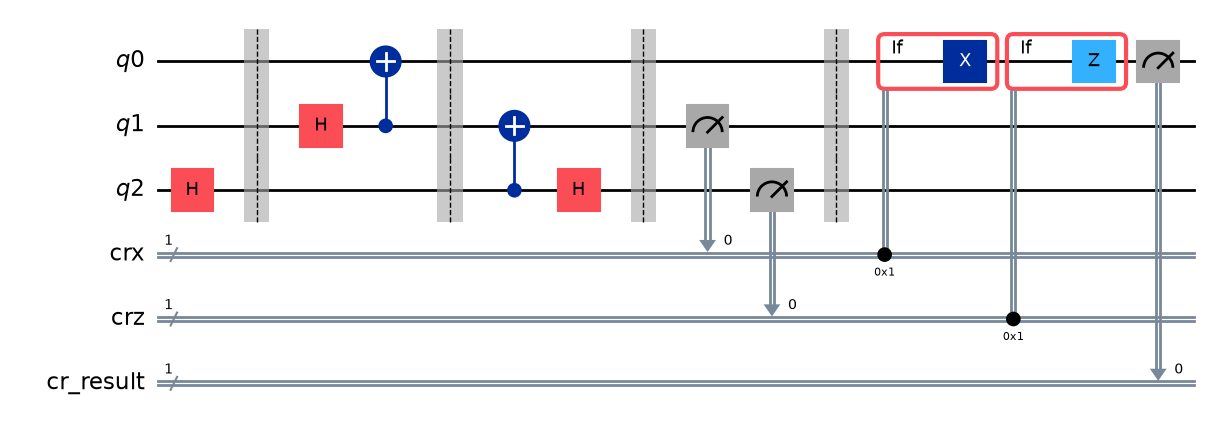

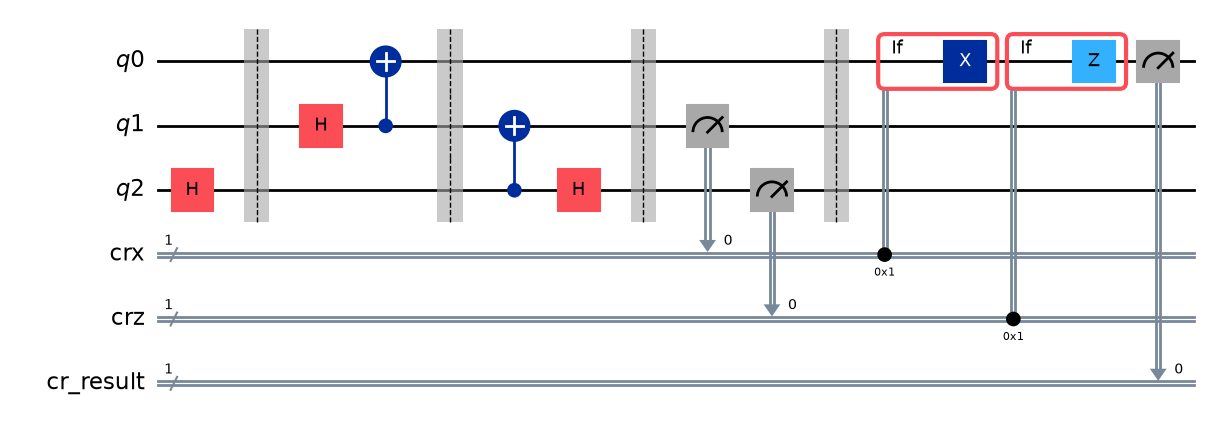

In [40]:
#Add final measurement to the destination qubit q0 to verify the teleportation
cr_result = ClassicalRegister(1, name='cr_result') # classical bit 'cr_result' to store the measurement of destination qubit q0
circuit.add_register(cr_result) #add the classical register to the circuit
circuit.measure(q0, cr_result) #measure the destination qubit q0 and store the result in classical bit 'cr_result'
circuit.draw(output='mpl') #draw the circuit with the final measurement

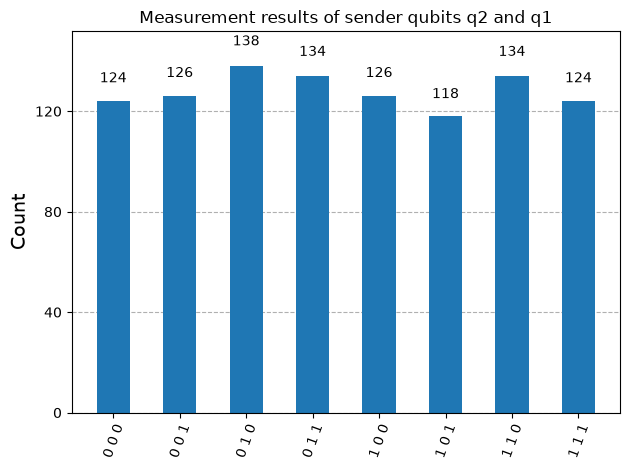

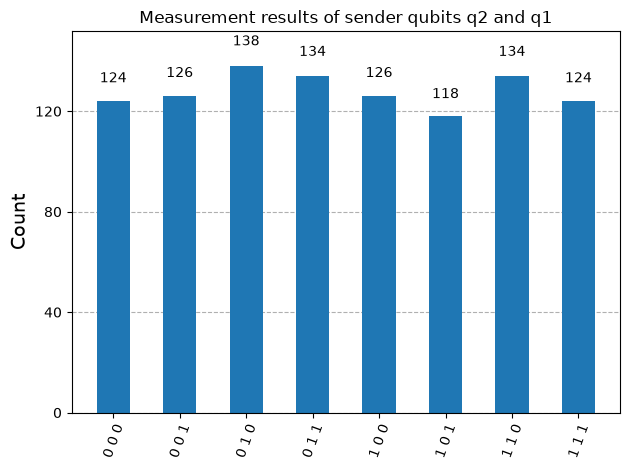

In [41]:
simulator = AerSimulator() #create a simulator object
compiled_circuit = transpile(circuit, simulator) #compile the circuit for the simulator
result = simulator.run(compiled_circuit).result() #run the simulation and get the result
counts = result.get_counts(compiled_circuit) #get the counts of the measurement results
plot_histogram(
    counts,
    title="Measurement results of sender qubits q2 and q1"
)

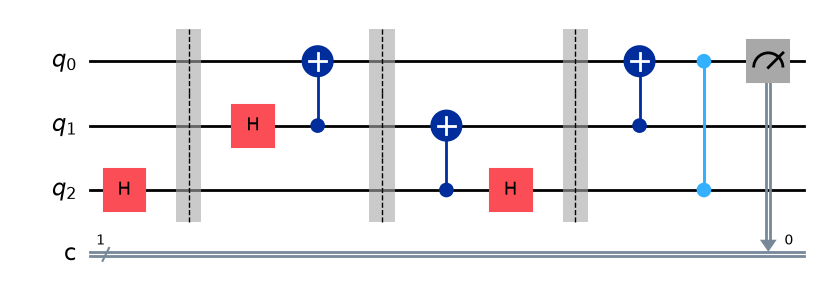

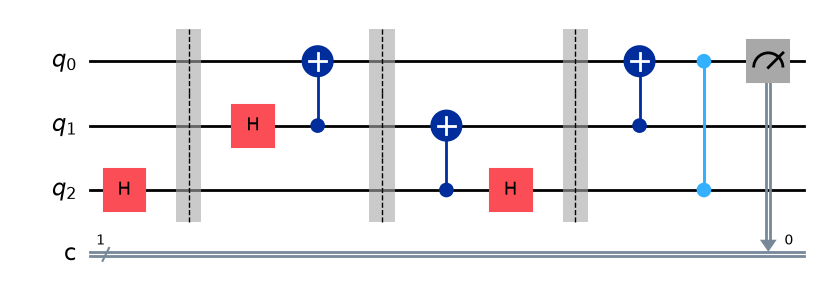

In [42]:
# quantum teleportation circuit using deferred measurement
circuit_def = QuantumCircuit(3, 1) #create a quantum circuit with 3 qubits and 1 classical bit

#initialize the source qubit q2 with a hadamard gate to create a superposition state
circuit_def.h(2) 
circuit_def.barrier()

#initialize the bell pair q1 and q0
circuit_def.h(1)
circuit_def.cx(1, 0)
circuit_def.barrier()

#perform a bell measurement on the source qubit q2 and the middle qubit q1
circuit_def.cx(2, 1)
circuit_def.h(2)
circuit_def.barrier()

#apply the correction gates to the destination qubit q0 based on the measurement results
circuit_def.cx(1, 0)
circuit_def.cz(2, 0)

#measure the destination qubit q0 to verify the teleportation
circuit_def.measure(0, 0)
circuit_def.draw(output='mpl') #draw the circuit with the final measurement

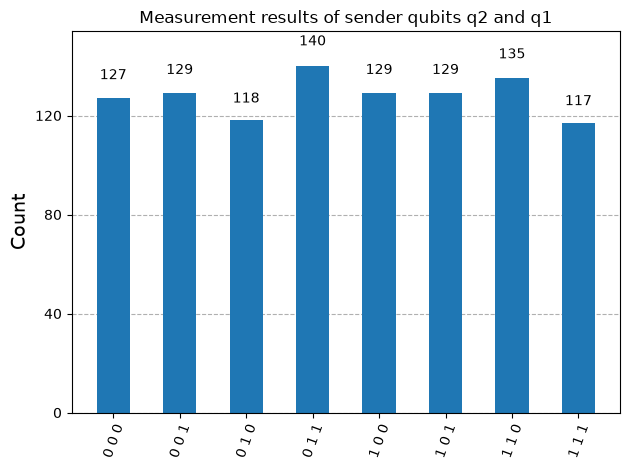

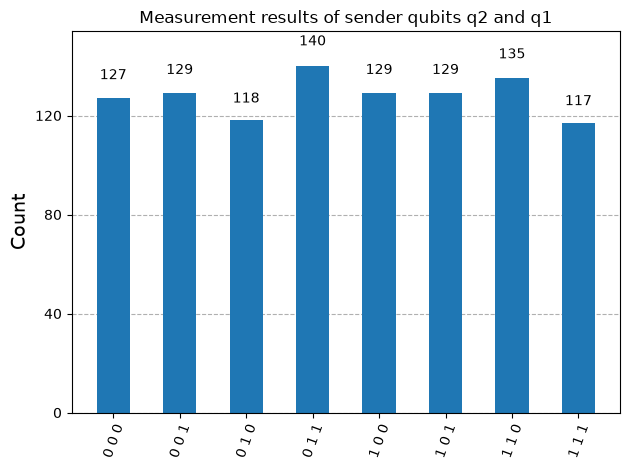

In [43]:
simulator = AerSimulator() #create a simulator object
compiled_circuit = transpile(circuit, simulator) #compile the circuit for the simulator
result = simulator.run(compiled_circuit).result() #run the simulation and get the result
counts = result.get_counts(compiled_circuit) #get the counts of the measurement results
plot_histogram(
    counts,
    title="Measurement results of sender qubits q2 and q1"
)